# Nivel 1


### Importacion bibliotecas

In [ ]:
import pandas as pd
import scipy 
import mysql.connector
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mysql.connector import Error
from datetime import datetime

### Ejercicio 1. Coneccion Python con MySQL Workbench


In [3]:

connection = None

try:
    connection = mysql.connector.connect(
        host='127.0.0.1',
        database='retail_analytics_db',
        user='root',
        password='1234'
    )
    if connection.is_connected():
        db_Info = connection.get_server_info()
        print("Connected to MySQL Server version ", db_Info)
        cursor = connection.cursor()
        cursor.execute("SELECT database();")
        record = cursor.fetchone()
        print("You're connected to database: ", record)
        
        products_df = pd.read_sql('SELECT * FROM products',connection)
        transaction_product_df = pd.read_sql('SELECT * FROM transaction_product',connection)
        transactions_df = pd.read_sql('SELECT * FROM transactions',connection)
        users_df = pd.read_sql('SELECT * FROM users',connection)
        
        print('Datos cargados con exito!')
        print(f'products: {len(products_df)} registros')
        print(f'transaction_product: {len(transaction_product_df)} registros')
        print(f'transactions: {len(transactions_df)} registros')
        print(f'users: {len(users_df)} registros')

except Error as e:
    print("Error while connecting to MySQL:", e)


finally:
    if connection is not None and connection.is_connected():
        cursor.close()
        connection.close()
        print("MySQL connection is closed")

C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_8408\1006453825.py:11: DeprecationWarning: Call to deprecated function get_server_info. Reason: 
    The property counterpart 'server_info' should be used instead.

  db_Info = connection.get_server_info()
C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_8408\1006453825.py:18: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  products_df = pd.read_sql('SELECT * FROM products',connection)
C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_8408\1006453825.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transaction_product_df = pd.read_sql('SELECT * FROM transaction_product',connection)


Connected to MySQL Server version  8.0.43
You're connected to database:  ('retail_analytics_db',)


C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_8408\1006453825.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  transactions_df = pd.read_sql('SELECT * FROM transactions',connection)


Datos cargados con exito!
products: 100 registros
transaction_product: 253391 registros
transactions: 100000 registros
users: 5000 registros
MySQL connection is closed


C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_8408\1006453825.py:21: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  users_df = pd.read_sql('SELECT * FROM users',connection)


### Ver DF descargados

In [44]:
print(users_df.shape)
users_df.head()


(5000, 11)


,ID,Name,Surname,Phone,Email,Birth_date,Country,City,Postal_code,Address,Age
0,1,Zeus,Gamble,1-282-581-0551,interdum.enim@protonmail.edu,1985-11-17,United States,New York,10001,348-7818 Sagittis St.\r,39
1,10,Robert,Mccarthy,(324) 746-6771,fermentum@protonmail.com,1984-04-30,United States,San Jose,95101,P.O. Box 773\r,41
2,100,Melodie,Mclean,1-677-221-7152,risus.varius@google.ca,1989-09-15,United States,San Jose,95101,Ap #644-8492 Sagittis St.\r,36
3,1000,Amkjrv,Qbulrxbp,+48-258-9936,amkjrv.qbulrxbp@example.com,1970-05-17,Germany,Stuttgart,70173,215 Qbulrxbp St\r,55
4,1001,Nfvrlb,Oydaiwbg,+94-121-2522,nfvrlb.oydaiwbg@example.com,1994-03-04,Germany,Cologne,50667,121 Oydaiwbg St\r,31


In [45]:
print(products_df.shape)
products_df.head()

(100, 6)


,id,product_name,price,colour,weight,warehouse_id
0,1,Direwolf Stannis,161.11,#7c7c7c,1.0,WH-4\r
1,10,Karstark Dorne,119.52,#f4f4f4,2.4,WH--5\r
2,100,south duel,40.43,#6d6d6d,3.0,WH--95
3,11,Karstark Dorne,49.70,#141414,2.7,WH--6\r
4,12,duel Direwolf,181.60,#a8a8a8,2.1,WH--7\r


In [46]:
print(transaction_product_df.shape)
transaction_product_df.head()

(253391, 2)


,transaction_id,product_id
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,66
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,30
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,72
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,18


In [47]:
print(transactions_df.shape)
transactions_df.head()

(100000, 9)


,ID,Card_id,Business_id,Timestamp,Amount,Declined,User_id,Lat,Longitude
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,4713,46.199929,1.435540
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,438,41.597206,12.221760
2,00045D6B-ED2E-4F2F-8186-CEE074D875D0,CcS-6699,b-2390,2020-07-14 15:37:45,326.01,0,2118,29.757296,-95.379637
3,000481C3-1C26-4FEF-83A0-4CD0EB004BBD,CcS-6696,b-2230,2017-09-04 19:44:53,161.60,0,2115,53.548884,-113.503053
4,00051AA4-9CBE-4268-B070-C38062A1B3E2,CcS-7606,b-2266,2017-01-05 18:19:25,148.91,0,3025,52.208370,5.690806


### Ejercicio 2

##### 1. Visualisacion de una variable numerica (Edad)

In [8]:
def calculate_age(birth_date):
    today = datetime.now()
    age = today.year - birth_date.year
    if (today.month, today.day) < (birth_date.month, birth_date.day):
        age -= 1
    return age

In [48]:
users_df['Age'] = users_df['Birth_date'].apply(calculate_age)
print(users_df.shape)
users_df[['ID','Birth_date','Age']].head()

(5000, 11)


,ID,Birth_date,Age
0,1,1985-11-17,39
1,10,1984-04-30,41
2,100,1989-09-15,36
3,1000,1970-05-17,55
4,1001,1994-03-04,31


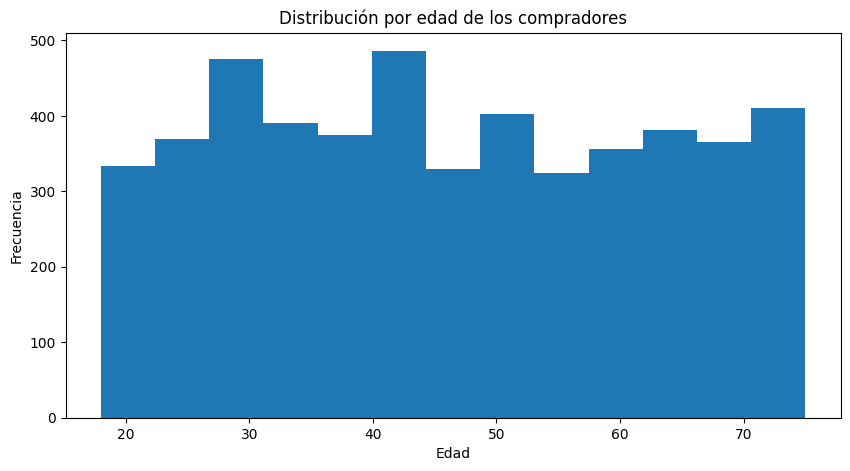

In [10]:
plt.figure(figsize=(10, 5))
plt.hist(users_df['Age'], bins=1 + int(np.log2(len(users_df))))
plt.title(f'Distribución por edad de los compradores')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

El gráfico muestra un histograma que ilustra la distribución de usuarios por edad. Los jóvenes y las personas de mediana edad (entre ~25 y ~45 años) son quienes realizan las compras con mayor frecuencia. En general, sin embargo, la distribución por edad de los usuarios es bastante uniforme. Se observa una ligera disminución en la frecuencia de compra entre los usuarios de ~45 a ~55 años, pero es insignificante.

##### 2. Visualisacion de dos variables numericas (Edad, Promedio de amount)

In [11]:
merged_df = transactions_df.merge(users_df, left_on='User_id', right_on='ID')
age_avg_amount = merged_df.groupby('Age')['Amount'].mean()
age_avg_amount = age_avg_amount.reset_index()

age_avg_amount.head()

,Age,Amount
0,18,262.658023
1,19,249.612584
2,20,261.188372
3,21,251.194126
4,22,261.021631


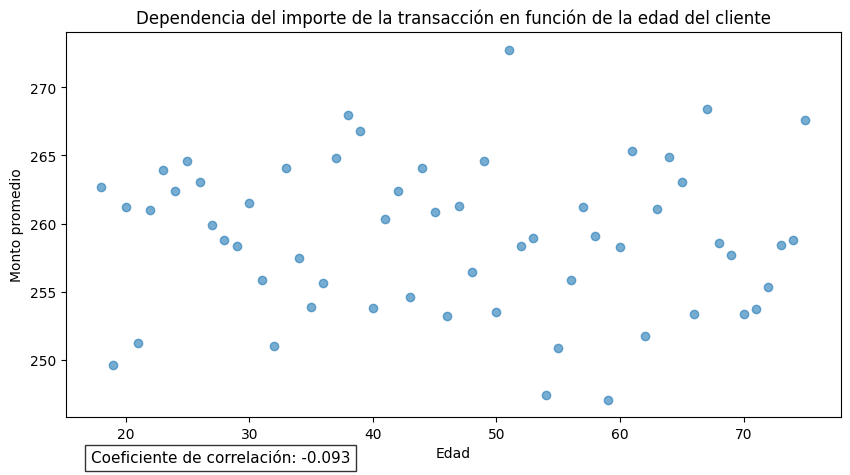

In [50]:
plt.figure(figsize=(10, 5))
plt.scatter(age_avg_amount['Age'], age_avg_amount['Amount'], alpha=0.6)
plt.title(f'Dependencia del importe de la transacción en función de la edad del cliente')
plt.xlabel('Edad')
plt.ylabel('Monto promedio')

corr = age_avg_amount['Age'].corr(age_avg_amount['Amount'], method = 'spearman')
plt.figtext(0.15, 0.02, f'Coeficiente de correlación: {corr:.3f}', 
           fontsize=11, bbox=dict(facecolor='white', alpha=0.8))

plt.show()

El gráfico que muestra la distribución del importe medio de las compras y la edad de los compradores muestra la relación con la edad del comprador que realiza la transacción. 
La distribución en el gráfico no muestra un patrón visible de aumento o disminución del ticket medio en función de la edad. En cualquier categoría de edad puede haber compradores que realicen transacciones de alta calidad con tickets de alto importe, así como compradores que realicen compras menos costosas. 

Para obtener una medida de evaluación más precisa y objetiva, también calculé el coeficiente de correlación de Spearman, que indica la existencia de una correlación negativa muy insignificante y débil entre estos indicadores. Teniendo en cuenta este hecho, no se puede concluir que el aumento del ticket medio esté relacionado con la disminución de la edad del comprador. La débil tendencia observada es, muy probablemente, casual y no refleja una dependencia real.

##### 3. Visualisacion de una variable categorica (Cantidad de usuarios por pais)

In [13]:
country_counts = users_df['Country'].value_counts()

country_counts

Country
United States     520
Canada            490
United Kingdom    478
Spain             461
Netherlands       455
Germany           452
Portugal          441
Italy             439
France            432
Sweden            417
Poland            415
Name: count, dtype: int64

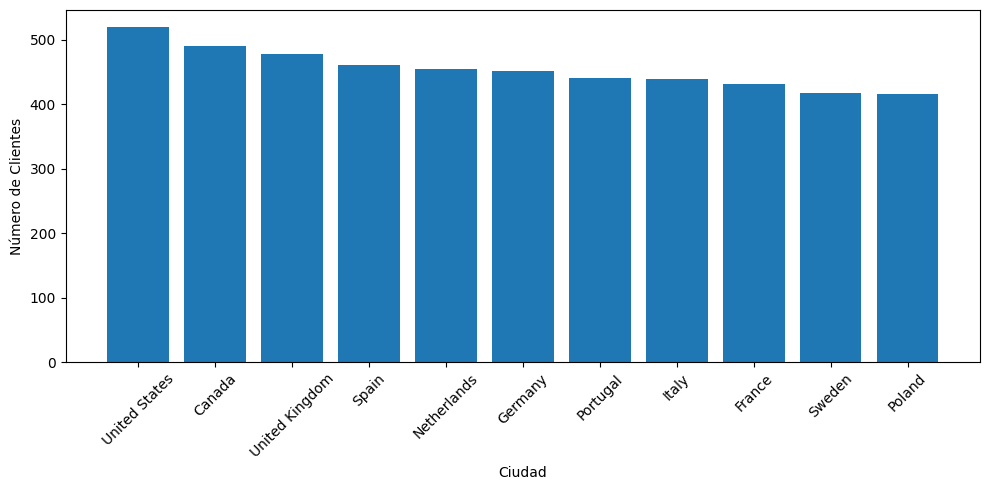

In [14]:
plt.figure(figsize=(10,5))
plt.bar(country_counts.index, country_counts.values)
plt.xlabel('Ciudad')
plt.ylabel('Número de Clientes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

El gráfico de columnas, que muestra los países y el número de clientes, muestra la distribución de los usuarios activos por países en los que la empresa realiza ventas. 
En nuestro caso, Estados Unidos tiene el mayor número de clientes y Polonia el menor. 
En mi opinión, este gráfico solo tiene sentido si se utiliza junto con otros indicadores y visualizaciones. Por ejemplo, el importe total de las ventas, el ticket medio, el número de oficinas, los datos sobre el perfil del comprador para evaluar los ingresos potenciales que se pueden alcanzar con el desarrollo de las ventas en ese país. 

##### 4. Visualisacion de una variable categorica y una numerica (Promedio de amount por  grupos de edad)

In [15]:

bins = [18, 25, 35, 45, 55, 65, 100]
labels = ['18-25','26-35','36-45','46-55','55-65','66+']

merged_df['Age_group'] = pd.cut(merged_df['Age'], bins = bins, labels = labels, right = False)
merged_df.head(2)

,ID_x,Card_id,Business_id,Timestamp,Amount,Declined,User_id,Lat,Longitude,ID_y,...,Surname,Phone,Email,Birth_date,Country,City,Postal_code,Address,Age,Age_group
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,4713,46.199929,1.43554,4713,...,Fjycossj,+87-307-6702,gxnmjn.fjycossj@example.com,1996-01-28,France,Marseille,13001,471 Fjycossj St\r,29,26-35
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,438,41.597206,12.22176,438,...,Azofeyj,+84-509-6735,kvkvekp.azofeyj@example.com,1957-08-16,Italy,Milan,20100,93 Azofeyj Street\r,68,66+


In [16]:
age_group_avg_amount = merged_df.groupby('Age_group')['Amount'].mean().reset_index()
age_group_avg_amount.head()

C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_8408\2698295633.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_avg_amount = merged_df.groupby('Age_group')['Amount'].mean().reset_index()


,Age_group,Amount
0,18-25,258.381810
1,26-35,259.353402
2,36-45,260.338903
3,46-55,258.955795
4,55-65,257.277654


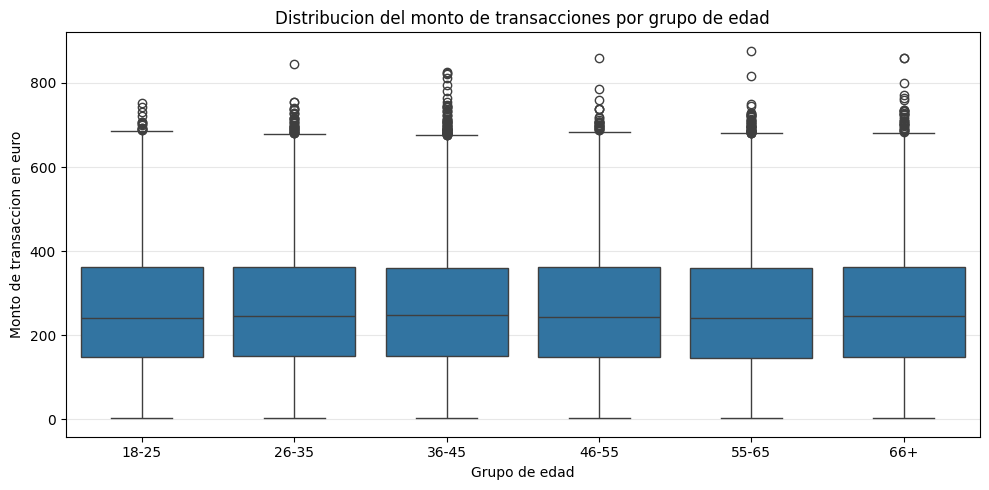

In [17]:
import seaborn as sns
plt.figure(figsize=(10, 5))

sns.boxplot(data = merged_df, x = 'Age_group', y = 'Amount')
plt.title('Distribucion del monto de transacciones por grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Monto de transaccion en euro')
plt.tight_layout()
plt.grid(axis='y', alpha = 0.3)
plt.show()

El diagrama de caja es una forma sencilla de comparar visualmente la distribución de una variable numérica en relación con una o varias variables categóricas. 
Así, según los gráficos presentados, se puede decir que la mayoría de las compras en cada grupo de edad se sitúan en valores inferiores a 400 euros, y que el importe medio de las compras supera los 200 euros, pero aún no alcanza los 300. 
Al mismo tiempo, en todos los grupos, excepto en el más joven (de 18 a 25 años), los usuarios realizan compras que superan los 800 euros. Estas compras son más habituales en los grupos de 36 a 45 años y de más de 66 años. Esto significa que a los compradores de estas categorías se les pueden ofrecer productos más caros, aumentando así el importe total de los tickets de compra. Los menos propensos a realizar compras que superen los 700 euros son los compradores del grupo de edad más joven. 

###### Cálculo de datos estadísticos para describir gráficos utilizando como ejemplo las categorías de edad. 

In [18]:
stats = merged_df.groupby('Age_group')['Amount'].agg(['median', 'std', 'count']).round(2)

max_median_group = stats['median'].idxmax()
max_median_value = stats['median'].max()

max_std_group = stats['std'].idxmax()
max_std_value = stats['std'].max()

stats

C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_8408\3567488046.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  stats = merged_df.groupby('Age_group')['Amount'].agg(['median', 'std', 'count']).round(2)


,median,std,count
Age_group,,,
18-25,241.54,148.36,10021
26-35,245.68,147.10,19236
36-45,246.86,147.41,20466
46-55,244.24,150.23,15817
55-65,239.72,149.32,16643
66+,244.87,149.25,17817


##### 5. Visualisacion de dos variables categoricas (Distribucion de usuarios por pais y grupo de edad)

In [19]:
cross_tab = pd.crosstab(merged_df['Country'], merged_df["Age_group"], normalize = 'index') * 100
cross_tab

Age_group,18-25,26-35,36-45,46-55,55-65,66+
Country,,,,,,
Canada,7.770879,24.103745,25.015021,12.908071,13.168436,17.033847
France,11.203856,16.200329,19.033623,17.140842,17.129085,19.292264
Germany,11.830792,18.216210,15.464863,18.055715,17.413734,19.018686
Italy,9.724492,17.616157,17.172543,16.133551,19.203829,20.149428
Netherlands,10.355987,16.605290,16.605290,16.694565,19.194286,20.544582
Poland,11.312545,16.944646,18.370800,15.155910,18.697124,19.518975
Portugal,10.815744,17.341700,18.322875,17.889333,16.212208,19.418140
Spain,12.890625,14.575893,17.522321,16.573661,19.910714,18.526786
Sweden,8.132085,17.434697,18.469690,18.900936,18.876294,18.186299


<Figure size 1000x800 with 0 Axes>

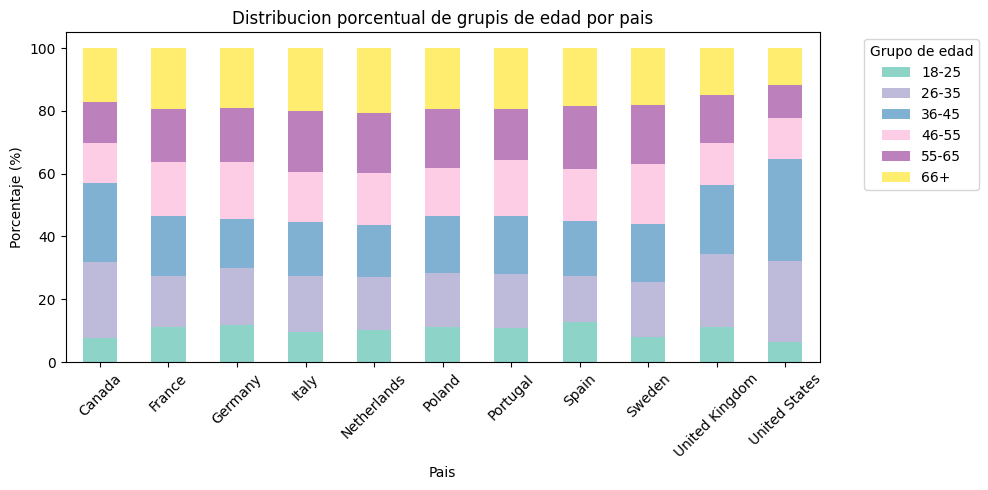

In [ ]:
plt.figure(figsize = (10, 8))
cross_tab.plot(kind = 'bar', 
               stacked=True, 
               figsize=(10, 5),
               colormap='Set3')

plt.title('Distribución de compradores por edades en relación con los países ')
plt.xlabel('País')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation = 45)
plt.legend(title = 'Grupo de edad', bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()

Según el gráfico agrupado de distribución de los grupos de edad de los compradores por países, se pueden extraer las siguientes conclusiones:
1. En países como Canadá, Reino Unido y Estados Unidos, los compradores son principalmente clientes de entre 26 y 45 años. 
Estos representan más del 50 % del total de compradores en estos países. Por lo tanto, el enfoque principal del marketing debe centrarse precisamente en estas categorías de usuarios. 

2. En el resto de países, que representan a Europa, la distribución es más uniforme, con una ligera ventaja de los grupos de edad a partir de los 55 años. 
Por ejemplo, en Italia, los Países Bajos y España, el público es más maduro. Por lo tanto, las campañas de marketing pueden centrarse en la promoción de productos entre estas categorías de población. 

3. El gráfico muestra claramente las áreas de crecimiento. Por ejemplo, la pequeña proporción de compradores jóvenes indica que la empresa debe esforzarse y dirigir sus campañas de marketing, por ejemplo, a otros canales para atraer a los jóvenes a su base de clientes. 

En mi opinión, este gráfico, como cualquier otro, solo tiene sentido si se combina con otras evaluaciones y análisis de la situación de las ventas en la empresa. Por ejemplo, un análisis preliminar de los hábitos de compra, como el del punto 4, ayudará a comprender qué productos de qué categorías de precios son los más habituales en las compras de cada grupo de consumidores y qué productos se pueden promocionar para influir en los KPI por países y grupos de compradores. 

##### 6 Visulisaciones de tres variables categoricas (Promedio de amount por grupo de edad y pais)

In [21]:
triple_analysis = merged_df.groupby(['Country', 'Age_group']).agg({
    'Amount': 'mean',
    'User_id': 'count'
}).reset_index()

triple_analysis.head()

C:\Users\ekaterinasorokopudov\AppData\Local\Temp\ipykernel_8408\440778336.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  triple_analysis = merged_df.groupby(['Country', 'Age_group']).agg({


,Country,Age_group,Amount,User_id
0,Canada,18-25,259.051830,776
1,Canada,26-35,262.811483,2407
2,Canada,36-45,261.804452,2498
3,Canada,46-55,257.506587,1289
4,Canada,55-65,253.832798,1315


In [22]:
pivot_table = triple_analysis.pivot(index='Country', 
                                   columns='Age_group', 
                                   values='Amount').round(2)

pivot_table.head()

Age_group,18-25,26-35,36-45,46-55,55-65,66+
Country,,,,,,
Canada,259.05,262.81,261.80,257.51,253.83,253.30
France,254.03,254.81,257.40,259.46,251.86,256.01
Germany,270.08,253.49,262.34,262.80,255.33,258.16
Italy,256.30,257.04,257.73,275.98,258.45,261.28
Netherlands,247.99,260.82,256.81,254.37,265.09,260.39


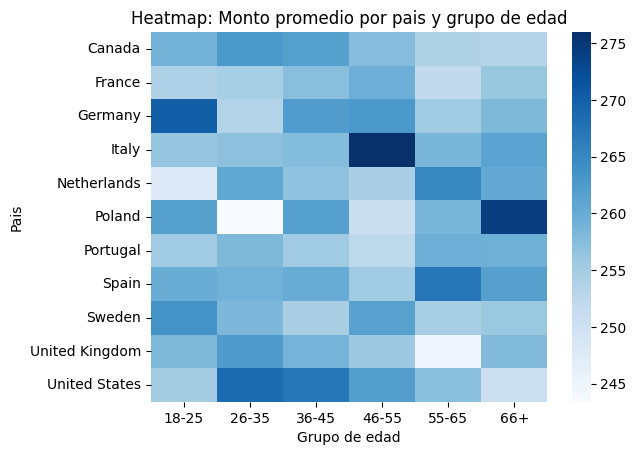

In [ ]:
sns.heatmap(pivot_table, annot=False, cmap='Blues')
plt.title('Heatmap: Monto promedio por país y grupo de edad')
plt.xlabel('Grupo de edad')
plt.ylabel('País')
plt.show()

Este gráfico muestra cómo se distribuye el importe medio de las ventas en relación con dos variables categóricas: el grupo de edad de los compradores y el país. 

A partir del gráfico, se puede evaluar qué grupo de edad realiza compras de mayor calidad con un ticket medio más alto. Esto ayuda a la empresa a evaluar la influencia del grupo de edad en la consecución de los KPI y a prever programas para atraer a las categorías de clientes más influyentes o estimular un comportamiento similar en otros grupos de edad o en los mismos grupos pero en otrao paises. 

En este gráfico se puede ver que la capacidad de compra más pronunciada se da entre los compradores italianos de entre 46 y 55 años. En el gráfico anterior se puede observar que este no es el grupo de consumidores más numeroso de la región. Por lo tanto, para aumentar las ventas, podemos planificar medidas dirigidas a atraer a los clientes de esta categoría.  

En segundo lugar, por el importe medio de la compra, destacan los usuarios mayores de 66 años de Polonia. En Polonia, la distribución de los compradores por grupos de edad es la más uniforme de todas las empresas. Al igual que en el caso de Italia, la empresa puede intentar atraer a nuevos compradores. Pero yo también sugeriría estudiar por qué los usuarios mayores de 66 años en Polonia realizan algunas de las compras de mayor calidad y si la empresa puede estimular un comportamiento similar entre los usuarios de esta categoría de edad en otros países. Por ejemplo, en Italia, los Países Bajos y Suecia, donde se encuentra la mayor proporción de estos compradores,  o en el Reino Unido, donde los usuarios de este mismo grupo realizan algunas de las compras de menor calidad. 

La empresa puede utilizar esta misma táctica tras estudiar en detalle las ventas en el Reino Unido entre usuarios de 26 a 35 años y aplicar la táctica de estimular las compras entre usuarios del mismo grupo de edad en Polonia, donde el indicador medio de gasto es 



##### 7. Pairplot (Dependencia de datos por producto)

In [24]:
product_transactions = transaction_product_df.merge(products_df, 
                                                    left_on = 'product_id', 
                                                    right_on = 'id', 
                                                    how = 'left').drop('id', axis=1)

product_transactions.head(2)

,transaction_id,product_id,product_name,price,colour,weight,warehouse_id
0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,the duel warden,180.91,#666666,3.0,WH--11\r
1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,66,mustafar jinn,2.12,#545454,0.8,WH--61\r


In [25]:
full_transaction_products_df = product_transactions.merge(transactions_df, 
                                                          left_on = 'transaction_id',
                                                          right_on = 'ID',
                                                          how = 'left').drop('ID', axis=1)
full_transaction_products_df = full_transaction_products_df.reset_index()

full_transaction_products_df.head(2)

,index,transaction_id,product_id,product_name,price,colour,weight,warehouse_id,Card_id,Business_id,Timestamp,Amount,Declined,User_id,Lat,Longitude
0,0,00043A49-2949-494B-A5DD-A5BAE3BB19DD,16,the duel warden,180.91,#666666,3.0,WH--11\r,CcS-9294,b-2458,2024-08-28 07:16:46,395.43,0,4713,46.199929,1.43554
1,1,000447FE-B650-4DCF-85DE-C7ED0EE1CAAD,66,mustafar jinn,2.12,#545454,0.8,WH--61\r,CcS-5019,b-2370,2016-12-21 20:07:18,155.63,0,438,41.597206,12.22176


In [ ]:

duplicates_count = full_transaction_products_df.duplicated().sum()
print(f"Número de duplicados en el marco de datos: {duplicates_count}")

if duplicates_count > 0:
    print("Duplicados:")
    print(full_transaction_products_df[full_transaction_products_df.duplicated()])
else:
    print("Duplicatas no encontradas")



Количество дубликатов в датафрейме: 0
Дубликатов нет


In [27]:
full_transaction_products_df.shape

(253391, 16)

In [37]:
product_analysis = full_transaction_products_df.groupby('product_id').agg({
    'price':'first',
    'transaction_id':'count',
    'Amount':['sum','mean'],
    'User_id':'nunique'
}).round(2)

product_analysis.columns = ['product_price','sales_count','total_revenue','average_sales_revenue','unique_customers']
product_analysis.shape


(100, 5)

<Figure size 2000x2500 with 0 Axes>

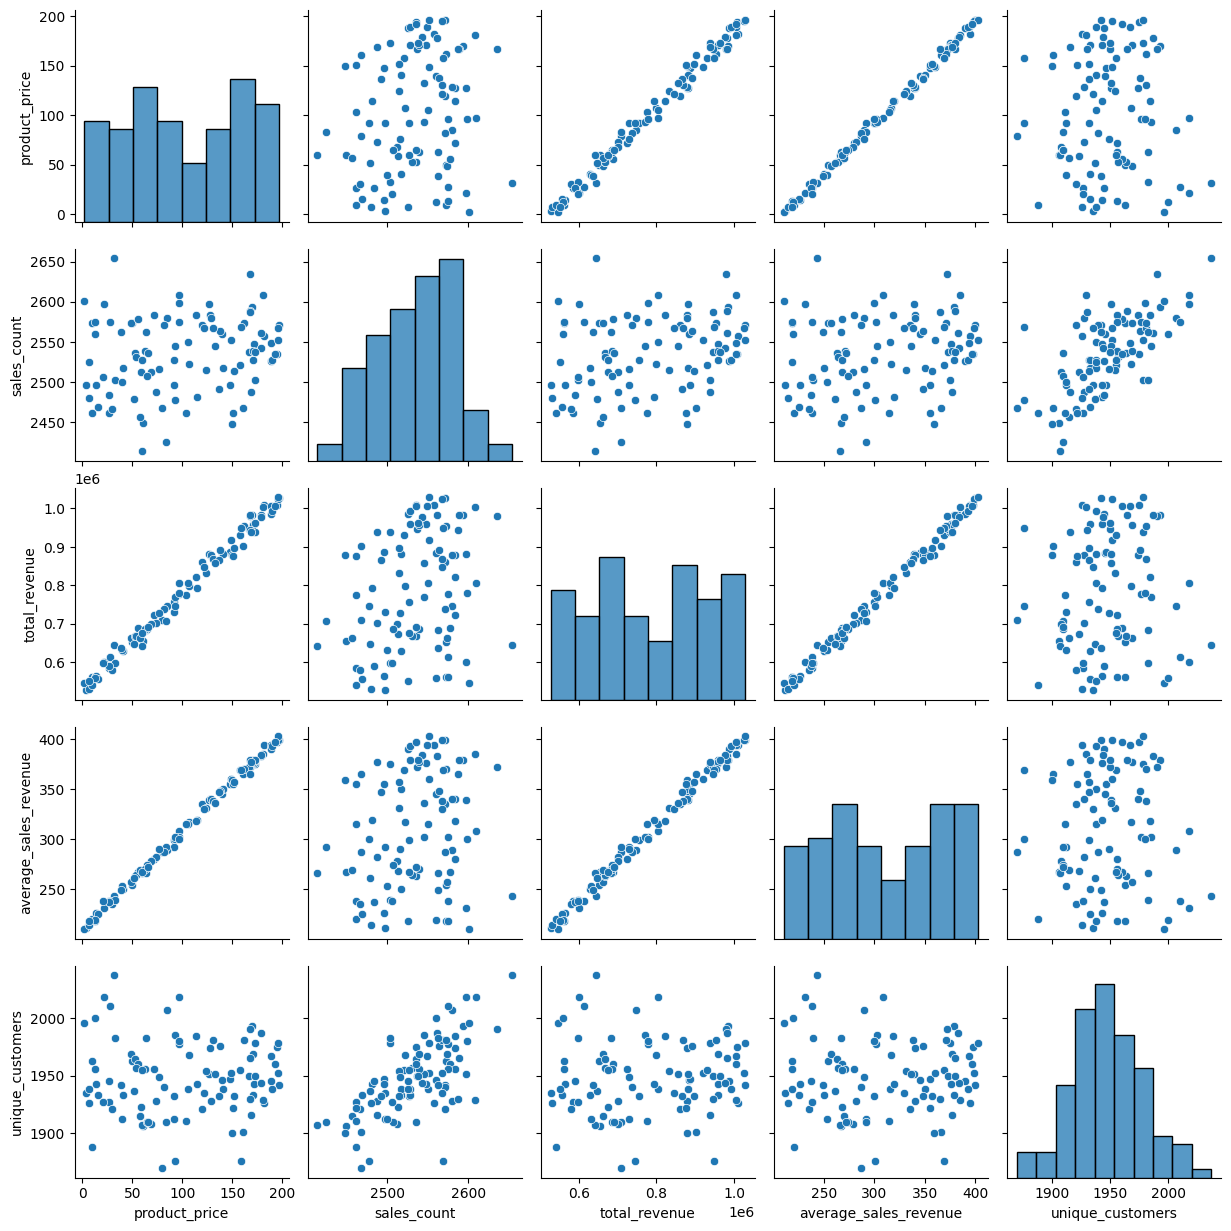

In [42]:
plt.figure(figsize=(20,25))
sns.pairplot(product_analysis)
plt.tight_layout
plt.show()

Pairplot es un conjunto de varios gráficos de distribución de variables numéricas. 
En la diagonal se pueden ver histogramas de distribución de la variable con frecuencia de repetición, y en otras intersecciones, gráficos de distribución de dos variables diferentes entre sí, para identificar la interrelación entre estos indicadores. 

En el gráfico que se muestra se analizan indicadores como el coste del producto, el número de ventas de productos, el importe de las ventas de productos, el importe medio de la factura en relación con los productos y el número de usuarios únicos que compran productos específicos. 

Gracias al gráfico, podemos ver que el importe de la transacción siempre aumenta cuando aumenta el precio del producto.  Y que el número de ventas aumenta si aumenta el número de usuarios. Esta dependencia no es tan evidente como la primera, pero sigue estando presente. A diferencia de la dependencia del número de compradores únicos en relación con el precio del producto. El gráfico muestra que el precio del producto puede ser completamente diferente para el mismo número de compradores únicos. Es decir, si 1950 clientes pueden comprar un producto por 50 euros, al mismo tiempo, exactamente el mismo número de clientes preferirá un producto por 150 euros. 

Por cierto, la mayoría de los productos tienen alrededor de 1950 consumidores únicos. 

# Nivel 2


### Ejercicio 1 Representa la correlación de algunas variables e interpreta los resultados según tus datos.

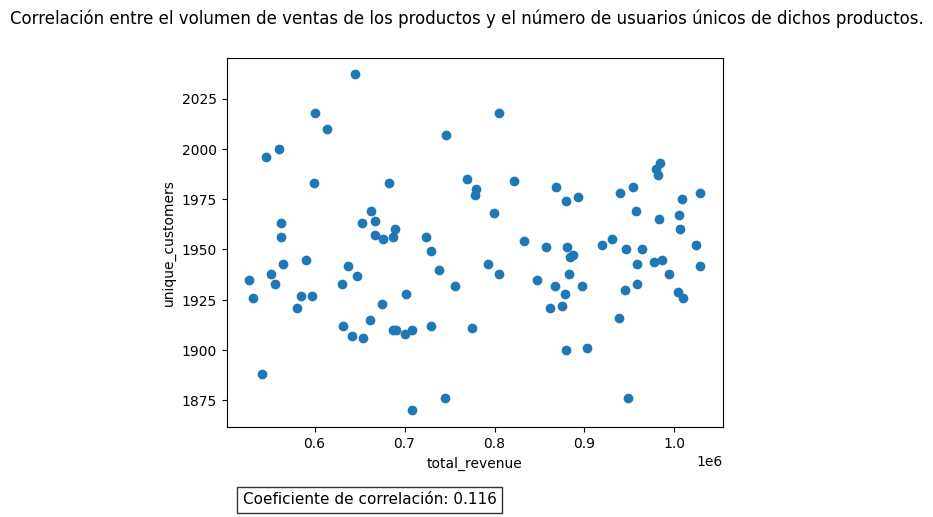

In [30]:
plt.scatter(product_analysis['total_revenue'], product_analysis['unique_customers'])
plt.suptitle('Correlación entre el volumen de ventas de los productos y el número de usuarios únicos de dichos productos.')
plt.xlabel('total_revenue')
plt.ylabel('unique_customers')
plt.tight_layout

corr = product_analysis['total_revenue'].corr(product_analysis['unique_customers'], method = 'spearman') 
plt.figtext(0.15, -0.05, f'Coeficiente de correlación: {corr:.3f}', 
           fontsize=11, bbox=dict(facecolor='white', alpha=0.8))
plt.show()

#### Analisis de correlaciones sin y con valores atipicos

In [31]:
def analyze_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    
    print(f"Análisis de valores atípicos {column}:")
    print(f"Límites estadísticos atípicos: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Cantidad de valores atípicos: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
    print(f"Min: {df[column].min():.2f}, Max: {df[column].max():.2f}")
    
    return outliers

In [32]:

amount_outliers = analyze_outliers(product_analysis, 'total_revenue')
print('\n')
amount_outliers = analyze_outliers(product_analysis, 'unique_customers')


Análisis de valores atípicos total_revenue:
Límites estadísticos atípicos: [250799.57, 1342182.30]
Cantidad de valores atípicos: 0 (0.0%)
Min: 527510.93, Max: 1028840.03


Análisis de valores atípicos unique_customers:
Límites estadísticos atípicos: [1867.00, 2029.00]
Cantidad de valores atípicos: 1 (1.0%)
Min: 1870.00, Max: 2037.00


In [33]:
# Con valores atípicos
corr_with_outliers = product_analysis['total_revenue'].corr(product_analysis['unique_customers'])

# Sin valores atípicos
Q1 = product_analysis['unique_customers'].quantile(0.25)
Q3 = product_analysis['unique_customers'].quantile(0.75)
IQR = Q3 - Q1
filtered_data = product_analysis[
    (product_analysis['unique_customers'] >= Q1 - 1.5*IQR) & 
    (product_analysis['unique_customers'] <= Q3 + 1.5*IQR)
]
corr_without_outliers = filtered_data['total_revenue'].corr(filtered_data['unique_customers'])

print(f"Comparación de correlaciones:")
print(f"Con valores atípicos: {corr_with_outliers:.3f}")
print(f"Sin valores atípicos: {corr_without_outliers:.3f}")
print(f"Diferencia: {abs(corr_with_outliers - corr_without_outliers):.3f}")

Comparación de correlaciones:
Con valores atípicos: 0.064
Sin valores atípicos: 0.095
Diferencia: 0.031


 ## Ejercicio 2 Implementa un Jointplot per explorar la relació entre dues variables i interpreta els resultats segons les teves dades.

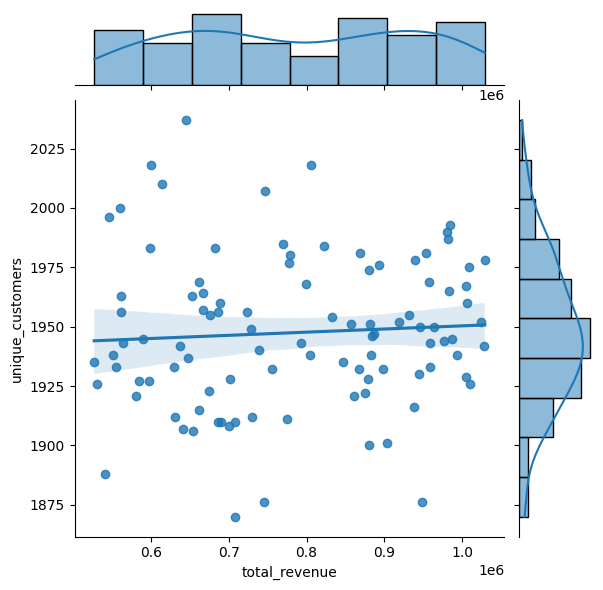

In [34]:
sns.jointplot(x = "total_revenue", y = "unique_customers",
              kind = "reg", data = product_analysis,
              dropna = True)
plt.show()

# Nivel 3

In [35]:
all_variables = dir()


dataframes = []
for var_name in all_variables:
    var_value = globals()[var_name]
    if isinstance(var_value, pd.DataFrame):
        dataframes.append((var_name))
        
print(dataframes)

['_', '_11', '_15', '_16', '_18', '_19', '_21', '_22', '_24', '_25', '_28', '_4', '_5', '_6', '_7', '_9', '___', 'age_avg_amount', 'age_group_avg_amount', 'amount_outliers', 'cross_tab', 'filtered_data', 'full_transaction_products_df', 'merged_df', 'pivot_table', 'product_analysis', 'product_transactions', 'products_df', 'stats', 'transaction_product_df', 'transactions_df', 'triple_analysis', 'users_df']


['age_avg_amount', 'age_group_avg_amount', 'amount_outliers', 'company_df', 'credit_card_status_df', 'credit_cards_df', 'cross_tab', 'filtered_data', 'full_transaction_products_df', 'merged_df', 'pivot_table', 'product_analysis', 'product_transactions', 'products_df', 'stats', 'transaction_product_df', 'transactions_df', 'triple_analysis', 'users_df']